In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
df = pd.read_csv("train.csv")
df.head()
df.shape

(74682, 4)

In [4]:
df.isnull().sum()

Id             0
Topic          0
Sentiment      0
Text         686
dtype: int64

In [5]:
df.dropna(inplace=True)

In [6]:
df.isnull().sum()

Id           0
Topic        0
Sentiment    0
Text         0
dtype: int64

In [7]:
df.shape

(73996, 4)

In [8]:
df.duplicated().sum()
df.shape

(73996, 4)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

def clean_text(text):
    text = text.lower()                              
    text = re.sub(r'[^a-z\s]', '', text)              
    text = ' '.join([word for word in text.split() if word not in stopwords.words('english')]) 
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\laeeq\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
df['Text'] = df['Text'].apply(clean_text)

<Axes: xlabel='Sentiment', ylabel='count'>

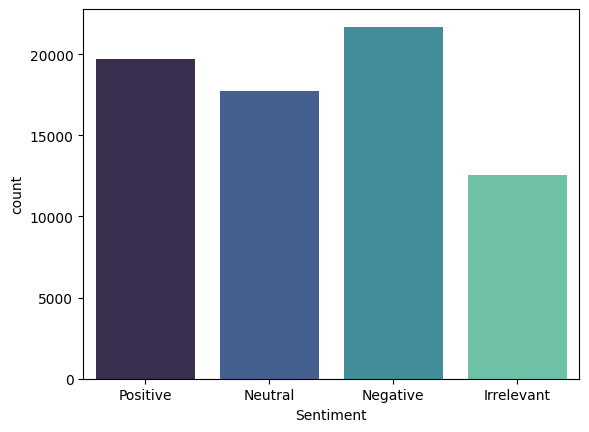

In [12]:
sns.countplot(data=df,x="Sentiment", hue=None, palette="mako")

In [13]:
df['Sentiment'].value_counts()

Sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64

In [14]:
df['Topic'].unique()

array(['Borderlands', 'CallOfDutyBlackopsColdWar', 'Amazon', 'Overwatch',
       'Xbox(Xseries)', 'NBA2K', 'Dota2', 'PlayStation5(PS5)',
       'WorldOfCraft', 'CS-GO', 'Google', 'AssassinsCreed', 'ApexLegends',
       'LeagueOfLegends', 'Fortnite', 'Microsoft', 'Hearthstone',
       'Battlefield', 'PlayerUnknownsBattlegrounds(PUBG)', 'Verizon',
       'HomeDepot', 'FIFA', 'RedDeadRedemption(RDR)', 'CallOfDuty',
       'TomClancysRainbowSix', 'Facebook', 'GrandTheftAuto(GTA)',
       'MaddenNFL', 'johnson&johnson', 'Cyberpunk2077',
       'TomClancysGhostRecon', 'Nvidia'], dtype=object)

In [15]:
# topics = df['Topic'].unique()
# for topic in topics:
#     plt.figure(figsize=(5,6))
#     subset = df[df['Topic']==topic]
#     sns.countplot(data=subset,x='Sentiment',palette="magma")
#     plt.title(topic)
#     plt.tight_layout()
#     plt.show()

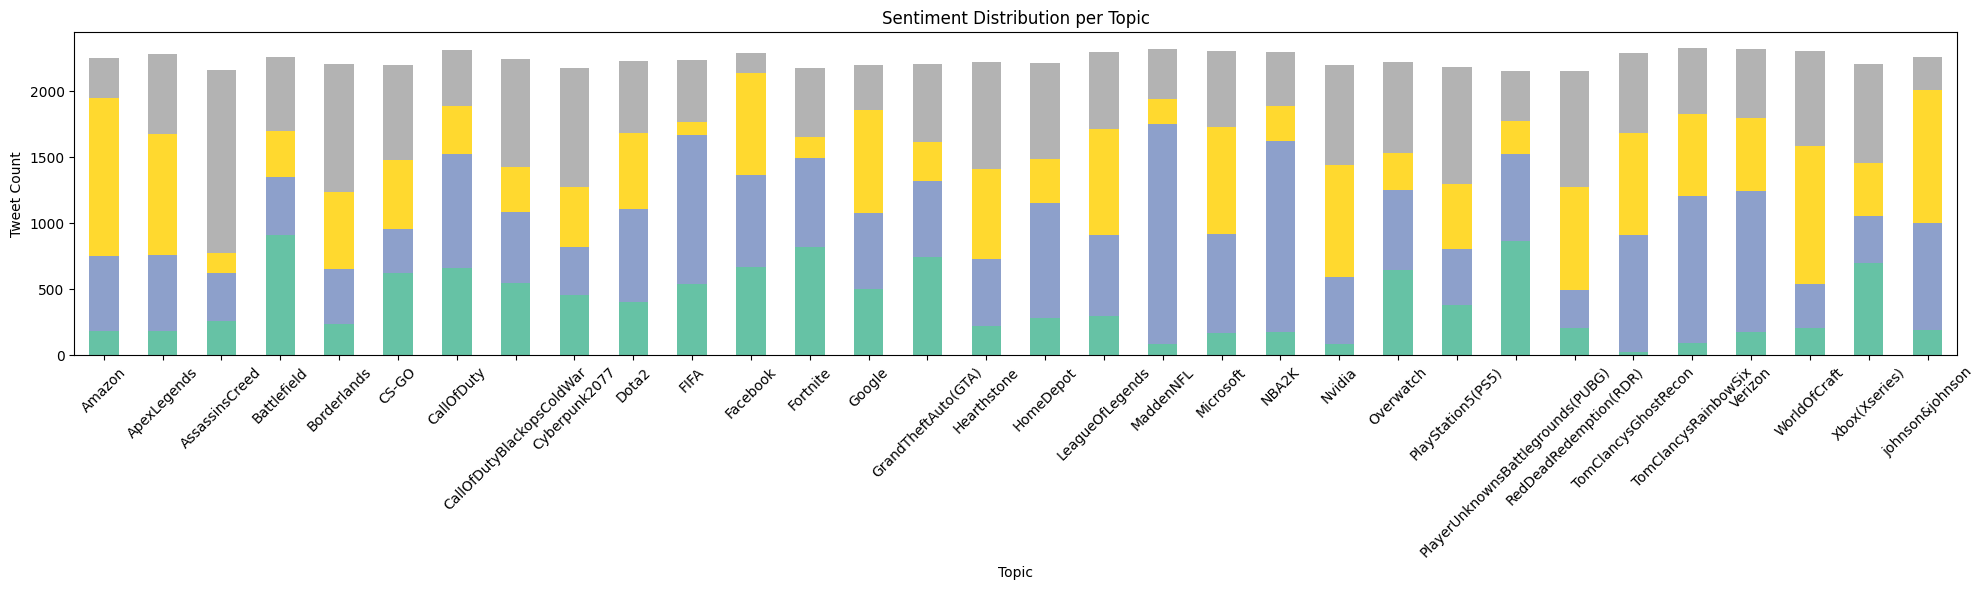

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

topic_sentiment = df.groupby(['Topic', 'Sentiment']).size().unstack().fillna(0)

# Stacked bar chart
topic_sentiment.plot(kind='bar', stacked=True, figsize=(20, 6), colormap='Set2',legend=False)
plt.title('Sentiment Distribution per Topic')
plt.xlabel('Topic')
plt.ylabel('Tweet Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


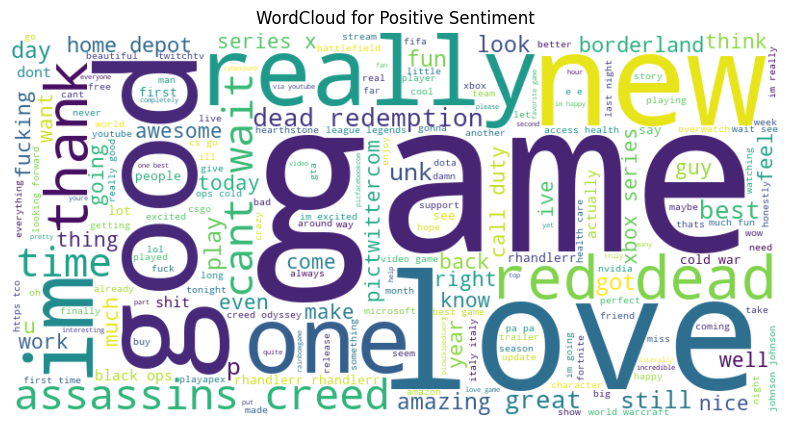

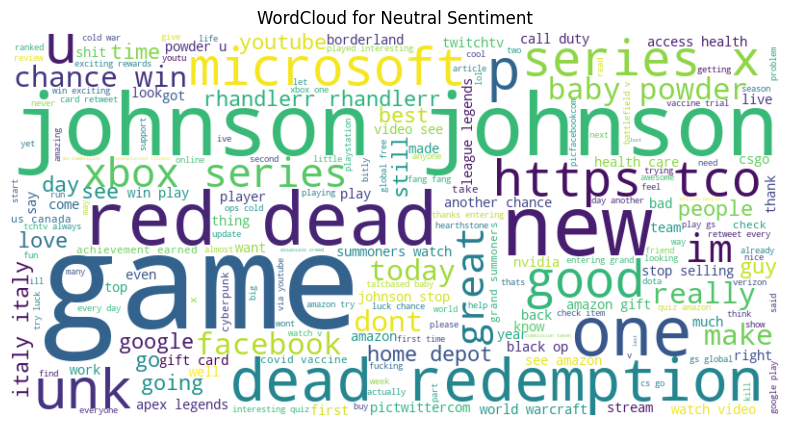

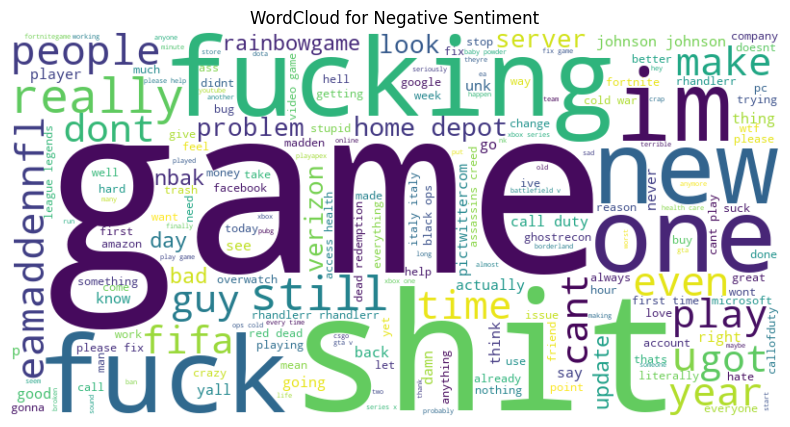

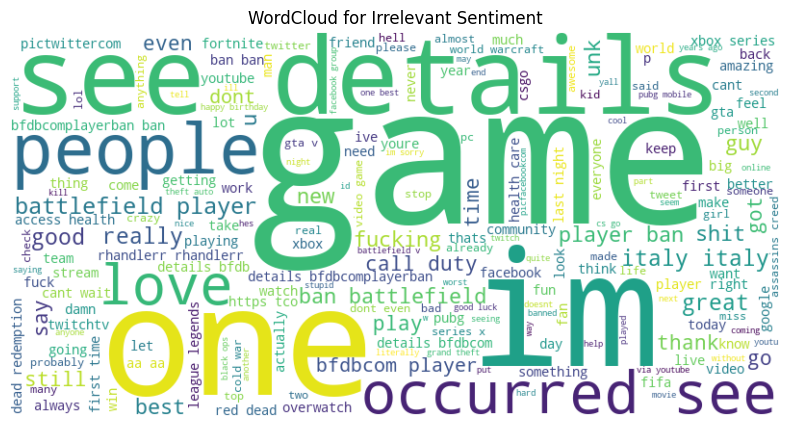

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for sentiment in df['Sentiment'].unique():
    text = ' '.join(df[df['Sentiment'] == sentiment]['Text'].astype(str))
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for {sentiment} Sentiment")
    plt.show()


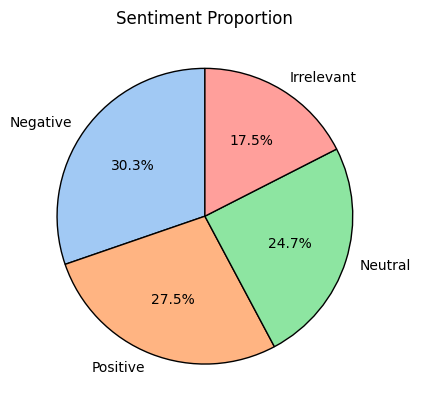

In [18]:
df['Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'black'})
plt.title("Sentiment Proportion")
plt.ylabel('')
plt.show()


In [19]:
df.head()

,Id,Topic,Sentiment,Text
0,2401,Borderlands,Positive,im getting borderlands murder
1,2401,Borderlands,Positive,coming borders kill
2,2401,Borderlands,Positive,im getting borderlands kill
3,2401,Borderlands,Positive,im coming borderlands murder
4,2401,Borderlands,Positive,im getting borderlands murder


In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sentiment'] = le.fit_transform(df['Sentiment'])


In [21]:
df.head()

,Id,Topic,Sentiment,Text
0,2401,Borderlands,3,im getting borderlands murder
1,2401,Borderlands,3,coming borders kill
2,2401,Borderlands,3,im getting borderlands kill
3,2401,Borderlands,3,im coming borderlands murder
4,2401,Borderlands,3,im getting borderlands murder


In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(df['Text'])
y = df['Sentiment']
train_x,test_x,train_y,test_y = train_test_split(x,y,test_size=0.75)
model = DecisionTreeClassifier()
model.fit(train_x,train_y)


DecisionTreeClassifier()

In [23]:
def test_model(text):
    text_vector = vectorizer.transform([text])
    pred = model.predict(text_vector)
    predic = le.inverse_transform(pred)
    print(f"{text}: {predic[0]}")

In [43]:
test_model("its not in use")

its not in use: Irrelevant


In [33]:
test_model('its good')

its good: Positive


In [26]:
test_model("shit")

shit: Negative


In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix
acc = accuracy_score(test_y, model.predict(test_x))
acc

0.6338245692382122

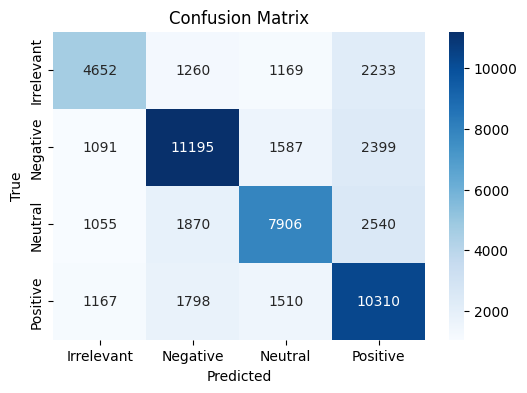

In [31]:
cm = confusion_matrix(test_y,model.predict(test_x))
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()